### Задание 1. Исследование данных и описательные статистики
1. Скачай файл duolingo.csv и загрузи данные.
2. Выполни первичный осмотр данных:
    * Выведи размер датасета: количество строк и колонок.
    * Покажи первые 5 строк: df.head().
    * Выведи названия колонок и типы данных.
    * Проверь пропущенные значения.
3. Выбери целевую метрику для анализа: p_recall_ab.
4. Раздели данные на группы A и B по колонке.
5. Проверь баланс групп: укажи количество записей в каждой группе.
6. Посчитай описательную статистику через NumPy для каждой группы:
    * среднее;
    * медиану;
    * стандартное отклонение;
    * минимум и максимум;
    * 25-й и 75-й перцентили.
7. Рассчитай разницу между группами:
    * абсолютная разница средних;
    * относительная разница в процентах.
8. Сделай первичный вывод:
    * укажи, какая группа показывает большее значение;
    * попробуй объяснить, что это может значить для продукта.
9. Сохрани файл project_8_task_1.ipynb и загрузи его в папку src.

In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd

# Загрузка данных
df = pd.read_csv('duolingo.csv')

# Размер датасета: количество строк и колонок
print("Размер датасета: ")
print(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")

Размер датасета: 
Строк: 500000, Колонок: 20


In [3]:
# Первые 5 строк
print("Первые 5 строк: ")
print(df.head())

Первые 5 строк: 
   p_recall   timestamp   delta user_id learning_language ui_language  \
0  1.000000  1362150681   69386  u:gQ-5                it          en   
1  1.000000  1362100988  337765  u:ftP9                de          en   
2  1.000000  1362149115    1332  u:g4KL                en          es   
3  1.000000  1362147615     500  u:hhBr                en          es   
4  0.666667  1362097652    1226  u:ijmS                en          es   

                          lexeme_id                  lexeme_string  \
0  fec119369ceb49cb5b6d72a58c3e770e    lui/lui<prn><tn><p3><m><sg>   
1  451bfa55bfd0e0f351d010de45fc6ffc  orangen/orange<n><f><pl><nom>   
2  01cc48f809e020f1dcbd4d33969395d2       february/february<n><sg>   
3  2179fd8c281cec0879b28ef81510bf9d         have/have<vblex><pres>   
4  a826c47947d68549fa81e19cafa57ba0           eat/eat<vblex><pres>   

   history_seen  history_correct  session_seen  session_correct  \
0            42               40             1          

In [4]:
# Названия колонок и типы данных
print("Колонки и типы данных")
print(df.dtypes)

Колонки и типы данных
p_recall             float64
timestamp              int64
delta                  int64
user_id                  str
learning_language        str
ui_language              str
lexeme_id                str
lexeme_string            str
history_seen           int64
history_correct        int64
session_seen           int64
session_correct        int64
experiment_group         str
review_strategy          str
delta_hours          float64
delta_days           float64
history_accuracy     float64
session_accuracy     float64
p_recall_ab          float64
retention_7d           int64
dtype: object


In [5]:
# Проверка пропущенных значений
print("Пропущенные значения")
# Выводим число пропущенных значений
print(df.isnull().sum())

Пропущенные значения
p_recall             0
timestamp            0
delta                0
user_id              0
learning_language    0
ui_language          0
lexeme_id            0
lexeme_string        0
history_seen         0
history_correct      0
session_seen         0
session_correct      0
experiment_group     0
review_strategy      0
delta_hours          0
delta_days           0
history_accuracy     0
session_accuracy     0
p_recall_ab          0
retention_7d         0
dtype: int64


In [6]:
# Целевая метрика — p_recall_ab
target = 'p_recall_ab'

# Разделение данных на группы А и В
group_a = df[df['experiment_group'] == 'A'][target].values # numpy-массив
group_b = df[df['experiment_group'] == 'B'][target].values # numpy-массив

# Проверка баланса групп
print(f"Группа А: {len(group_a)} записей")
print(f"Группа В: {len(group_b)} записей")
if len(group_a) == len(group_b):
    print("Группы одинакового размера")
else:
    print("Группы разного размера")

Группа А: 250429 записей
Группа В: 249571 записей
Группы разного размера


In [7]:
# Описательная статистика через NumPy
def print_stats(name, data):
    """Выводит описательную статистику для группы"""
    print(f"\n{name}")
    print(f"* Среднее:              {np.mean(data):.4f}")
    print(f"* Медиана:              {np.median(data):.4f}")
    print(f"* Стд. отклонение:      {np.std(data):.4f}")
    print(f"* Минимум:              {np.min(data):.4f}")
    print(f"* Максимум:             {np.max(data):.4f}")
    print(f"* 25-й перцентиль:      {np.percentile(data, 25):.4f}")
    print(f"* 75-й перцентиль:      {np.percentile(data, 75):.4f}")
    
print_stats("Группа А (контрольная)", group_a)
print_stats("Группа В (тестовая)", group_b)


Группа А (контрольная)
* Среднее:              0.8754
* Медиана:              0.9624
* Стд. отклонение:      0.2220
* Минимум:              0.0000
* Максимум:             1.0000
* 25-й перцентиль:      0.8800
* 75-й перцентиль:      1.0000

Группа В (тестовая)
* Среднее:              0.8951
* Медиана:              0.9971
* Стд. отклонение:      0.2151
* Минимум:              0.0000
* Максимум:             1.0000
* 25-й перцентиль:      0.9149
* 75-й перцентиль:      1.0000


In [8]:
# 7. Разница между группами

mean_a = np.mean(group_a)
mean_b = np.mean(group_b)

abs_diff = mean_b - mean_a           # абсолютная разница
rel_diff = (abs_diff / mean_a) * 100 # относительная разница

print(f"* Среднее группы А:        {mean_a:.4f}")
print(f"* Среднее группы В:        {mean_b:.4f}")
print(f"* Абсолютная разница:      {abs_diff:+.4f}")
print(f"* Относительная разница:   {rel_diff:+.2f}%")

* Среднее группы А:        0.8754
* Среднее группы В:        0.8951
* Абсолютная разница:      +0.0197
* Относительная разница:   +2.25%


### Первичный вывод

*  Какая группа показывает большее значение
> Группа В показывает большее значение.

* Попробуй объяснить, что это может значить для продукта
> Это означает, что новая стратегия повторения слов даёт чуть более высокий процент правильного воспоминания. Это значит, что даже если разница реальна, её практическое влияние на продукт, скорее всего, будет слабым — пользователи вряд ли заметят улучшение

### Задание 2. Проведение A/B-теста (t-тест)
1. Проведи t-тест для метрики p_recall_ab.
2. Интерпретируй p-value:
    * сравни p-value с порогом значимости 0.05;
    * сделай вывод: разница значима или может быть случайной.
3. Оцени размер эффекта:
    * рассчитай абсолютную разницу средних;
    * рассчитай относительную разницу в процентах;
    * оцени величину эффекта: малая <5%, умеренная 5–15%, большая >15%.
4. Сформулируй итоговый вывод:
    * Укажи, какая группа показывает лучший результат.
    * Укажи, можно ли доверять этому результату.
5. Опционально визуализируй распределение:
    * построй гистограммы для групп A и B;
    * добавь вертикальные линии средних значений.
6. Сохрани файл project_8_task_2.ipynb и загрузи его в папку src.

In [10]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('duolingo.csv')
target = 'p_recall_ab'
group_a = df[df['experiment_group'] == 'A'][target].values
group_b = df[df['experiment_group'] == 'B'][target].values

# Проводим t-тест
# t_stat показывает, насколько сильно средние двух групп отличаются друг от друга
# p_value показывет какова вероятность того, что разница между средними значениями значима (не случайна)
t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

print("Результаты t-теста")
print(f"* t-статистика:        {t_stat:.4f}")
print(f"* p-value:             {p_value:.6f}")
print(f"* Порог значимости:    0.05")

Результаты t-теста
* t-статистика:        -31.8172
* p-value:             0.000000
* Порог значимости:    0.05


In [11]:
# Интерпретация p-value

print("Интерпритация p-value")

if p_value < 0.05:
    print(f"  p-value ({p_value:.6f}) < 0.05")
    print(" Разница СТАТИСТИЧЕСКИ ЗНАЧИМА")
    print(" Маловероятно, что такая разница возникла случайно")
else:
    print(f"  p-value ({p_value:.6f}) ≥ 0.05")
    print(" Разница НЕ ЗНАЧИМА")
    print(" Такая разница могла возникнуть случайно")

Интерпритация p-value
  p-value (0.000000) < 0.05
 Разница СТАТИСТИЧЕСКИ ЗНАЧИМА
 Маловероятно, что такая разница возникла случайно


In [12]:
# Оценка размера эффекта

mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
abs_diff = mean_b - mean_a
rel_diff = (abs_diff / mean_a) * 100

print("Размер эффекта")
print(f"* Среднее группы А:        {mean_a:.4f}")
print(f"* Среднее группы В:        {mean_b:.4f}")
print(f"* Абсолютная разница:      {abs_diff:+.4f}")
print(f"* Относительная разница:   {rel_diff:+.2f}%")

# Берём модуль
abs_rel = abs(rel_diff)
if abs_rel < 5:
    effect = "МАЛЫЙ (<5%)"
elif abs_rel < 15:
    effect = "УМЕРЕННЫЙ (5–15%)"
else:
    effect = "БОЛЬШОЙ (>15%)"
print(f"* Величина эффекта:        {effect}, {abs_rel}")

Размер эффекта
* Среднее группы А:        0.8754
* Среднее группы В:        0.8951
* Абсолютная разница:      +0.0197
* Относительная разница:   +2.25%
* Величина эффекта:        МАЛЫЙ (<5%), 2.247140416906307


In [13]:
# Итоговый вывод

print("Итоговый вывод")

if mean_b > mean_a:
    better = "В (smart_review)"
else:
    better = "А (standard_review)"

print(f"* Лучший результат показывает группа: {better}")
print(f"* Разница: {abs_diff:+.4f} ({rel_diff:+.2f}%)")

if p_value < 0.05:
    print("* Разница статистически значима — результату можно доверять")
else:
    print("* Разница статистически НЕ значима — доверять результату нельзя")

Итоговый вывод
* Лучший результат показывает группа: В (smart_review)
* Разница: +0.0197 (+2.25%)
* Разница статистически значима — результату можно доверять


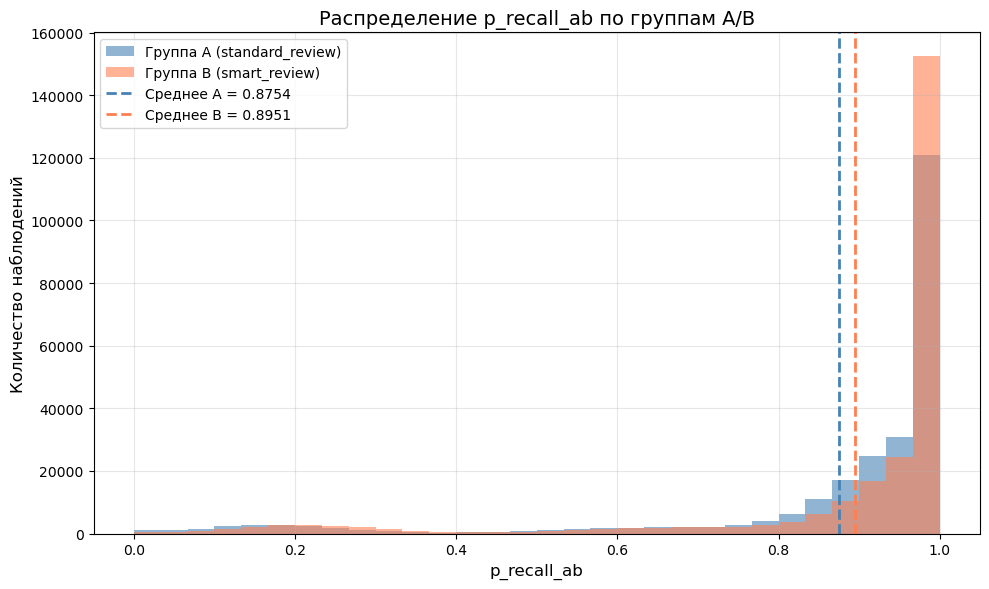

In [14]:
# Визуализация распределения

plt.figure(figsize=(10, 6))

plt.hist(group_a, bins=30, alpha=0.6, label='Группа А (standard_review)', color='steelblue')
plt.hist(group_b, bins=30, alpha=0.6, label='Группа В (smart_review)', color='coral')

plt.axvline(mean_a, color='steelblue', linestyle='--', linewidth=2,
            label=f'Среднее А = {mean_a:.4f}')
plt.axvline(mean_b, color='coral', linestyle='--', linewidth=2,
            label=f'Среднее В = {mean_b:.4f}')

plt.title('Распределение p_recall_ab по группам A/B', fontsize=14)
plt.xlabel('p_recall_ab', fontsize=12)
plt.ylabel('Количество наблюдений', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# p_recall_ab - Это метрика, которая показывает, какую долю слов пользователь правильно вспомнил после применения стратегии повторения.
# Синяя - до изменения
# Красная - после изменения (тестовая группа)

### Задание 3. Анализ конверсии
1. Посчитай конверсию в каждой группе, выведи результат в процентах для группы A и группы B.

> Тут конверсия — это доля пользователей или наблюдений, где retention_7d = 1.

2. Проведи тест для сравнения долей: хи-квадрат тест.
    * Создай таблицу сопряжённости.
    * Выведи p-value в консоль.
3. Интерпретируй результат:
    * сравни p-value| с порогом 0.05;
    * сделай вывод: разница в конверсии значима или может быть случайной.
4. Сформулируй итоговую рекомендацию:
    * если разница значима и конверсия B > A → «Рекомендуем внедрить версию B»;
    * если разница значима и конверсия B < A → «Рекомендуем доработать версию B»;
    * если разница не значима → «Недостаточно данных для вывода, протестируем ещё раз».
5. Сохрани файл project_8_task_3.ipynb и загрузи его в папку src.

In [15]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Загружаем данные
df = pd.read_csv('duolingo.csv')

In [16]:
# Считаем конверсию в каждой группе
group_a = df[df['experiment_group'] == 'A']
group_b = df[df['experiment_group'] == 'B']

# Количество записей в каждой группе
n_a = len(group_a)
n_b = len(group_b)

# Сколько "вернувшихся" (retention_7d == 1)
ret_a = group_a['retention_7d'].sum()
ret_b = group_b['retention_7d'].sum()

# Конверсия в процентах
conv_a = ret_a / n_a * 100
conv_b = ret_b / n_b * 100

print("Конверсия (retention_7d)")
print(f" Группа А (standard_review):")
print(f"* Всего записей:        {n_a}")
print(f"* Вернулись (ret=1):    {ret_a}")
print(f"* Конверсия:            {conv_a:.2f}%")
print()
print(f" Группа В (smart_review):")
print(f"* Всего записей:        {n_b}")
print(f"* Вернулись (ret=1):    {ret_b}")
print(f"* Конверсия:            {conv_b:.2f}%")

# Разница
abs_diff = conv_b - conv_a
rel_diff = (abs_diff / conv_a) * 100
print()
print(f"* Абсолютная разница:      {abs_diff:+.2f} ")
print(f"* Относительная разница:   {rel_diff:+.2f}%")

Конверсия (retention_7d)
 Группа А (standard_review):
* Всего записей:        250429
* Вернулись (ret=1):    161890
* Конверсия:            64.65%

 Группа В (smart_review):
* Всего записей:        249571
* Вернулись (ret=1):    169409
* Конверсия:            67.88%

* Абсолютная разница:      +3.24 
* Относительная разница:   +5.00%


In [17]:
# Хи-квадрат тест для сравнения долей

# Считаем "не вернувшихся"
not_ret_a = n_a - ret_a
not_ret_b = n_b - ret_b

# Таблица сопряжённости
contingency_table = np.array([
    [ret_a, not_ret_a],   # строка А
    [ret_b, not_ret_b]    # строка В
])

print("Таблица сопряжённости")
print(f"                | Вернулся | Не вернулся |")
print(f"  Группа А      | {ret_a:>8} | {not_ret_a:>11} |")
print(f"  Группа В      | {ret_b:>8} | {not_ret_b:>11} |")

# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print()
print("Результаты хи-квадрат теста")
print(f"* Хи-квадрат:              {chi2:.4f}")
print(f"* p-value:                 {p_value:.6f}")
print(f"* Степени свободы:         {dof}")
print(f"* Порог значимости:        0.05")

Таблица сопряжённости
                | Вернулся | Не вернулся |
  Группа А      |   161890 |       88539 |
  Группа В      |   169409 |       80162 |

Результаты хи-квадрат теста
* Хи-квадрат:              584.9997
* p-value:                 0.000000
* Степени свободы:         1
* Порог значимости:        0.05


In [18]:
# Интерпретация результата

if p_value < 0.05:
    print(f"  p-value ({p_value:.6f}) < 0.05")
    print("- Разница в конверсии СТАТИСТИЧЕСКИ ЗНАЧИМА")
    print("- Маловероятно, что она возникла случайно")
    significant = True
else:
    print(f"  p-value ({p_value:.6f}) ≥ 0.05")
    print("- Разница в конверсии НЕ ЗНАЧИМА")
    print("- Она могла возникнуть случайно")
    significant = False

  p-value (0.000000) < 0.05
- Разница в конверсии СТАТИСТИЧЕСКИ ЗНАЧИМА
- Маловероятно, что она возникла случайно


In [19]:
# Итоговая интерпретация

if significant:
    if conv_b > conv_a:
        print(" Рекомендуем ВНЕДРИТЬ версию В (smart_review)")
        print(f" Конверсия В ({conv_b:.2f}%) значимо выше, чем в А ({conv_a:.2f}%)")
    else:
        print(" Рекомендуем ДОРАБОТАТЬ версию В (smart_review)")
        print(f" Конверсия В ({conv_b:.2f}%) значимо ниже, чем в А ({conv_a:.2f}%)")
else:
    print(" Недостаточно данных для вывода")
    print(" Разница не значима — протестируем ещё раз")
    print(f" (В = {conv_b:.2f}%, А = {conv_a:.2f}%, p = {p_value:.4f})")

 Рекомендуем ВНЕДРИТЬ версию В (smart_review)
 Конверсия В (67.88%) значимо выше, чем в А (64.65%)
